# Contrastive Loss

The Image Encoder and Text Encoder can now independently transform images and captions into vectors in the same shared embedding space.

The next question is:

> How do we train the two encoders so that matching images and captions become close together?

We use **contrastive learning**.

The basic idea is:

```text
Image
  ↓
Image Encoder
  ↓
Image Embedding

Caption
  ↓
Text Encoder
  ↓
Text Embedding

Image Embedding + Text Embedding
              ↓
       Similarity Matrix
              ↓
      Contrastive Loss


## 1. Contrastive Learning

Contrastive learning teaches a model by comparing examples against one another.

Instead of asking the model to predict a class such as:

```text
red
circle
top-left

we ask it to learn relationships between representations.

## 2. Positive and Negative Pairs

Suppose a batch contains three aligned image-caption pairs:

| Image | Caption |
|---|---|
| I₁ | T₁ |
| I₂ | T₂ |
| I₃ | T₃ |

The matching pairs are **positive pairs**:

```text
I₁ ↔ T₁
I₂ ↔ T₂
I₃ ↔ T₃

The other combinations are negative pairs:

I₁ ↔ T₂
I₁ ↔ T₃

I₂ ↔ T₁
I₂ ↔ T₃

I₃ ↔ T₁
I₃ ↔ T₂

The important property of CLIP-style training is that we can obtain many negative examples naturally from the same batch.

For example:

I₁ ↔ T₁  → positive
I₁ ↔ T₂  → negative
I₁ ↔ T₃  → negative

## 3. Obtain Image and Text Embeddings

We now use the existing:

- `train_loader`
- Image Encoder
- Text Encoder
- tokenizer

We do **not** recreate the dataset.

For one batch we want:

$$
Z_I \in \mathbb{R}^{B \times D}
$$

and:

$$
Z_T \in \mathbb{R}^{B \times D}
$$

where:

- $B$ = batch size
- $D$ = shared embedding dimension

For this project:

$$
D = 64
$$

The image and caption at the same batch position represent a matching pair.

```text
images[0]  ↔ captions[0]
images[1]  ↔ captions[1]
images[2]  ↔ captions[2]
...

In [169]:
from pathlib import Path
import sys
from torch import nn
import torch
import torch.nn.functional as F


In [170]:
# ============================================================
# Contrastive Loss — Input Setup
# ============================================================



# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


# ------------------------------------------------------------
# Artifact directories
# ------------------------------------------------------------

MODEL_ARTIFACTS_DIR = (
    PROJECT_ROOT / "artifacts" / "models"
)

FIGURES_DIR = (
    PROJECT_ROOT / "assets" / "figures"
)

MODEL_ARTIFACTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ------------------------------------------------------------
# Load representative embeddings
# ------------------------------------------------------------

image_embeddings = torch.load(
    MODEL_ARTIFACTS_DIR / "image_embeddings_initial.pt",
    weights_only=True,
).to(DEVICE)

text_embeddings = torch.load(
    MODEL_ARTIFACTS_DIR / "text_embeddings_initial.pt",
    weights_only=True,
).to(DEVICE)


# ------------------------------------------------------------
# Verify inputs
# ------------------------------------------------------------

print("Device:", DEVICE)

print(
    "Image embeddings:",
    image_embeddings.shape,
)

print(
    "Text embeddings:",
    text_embeddings.shape,
)

assert image_embeddings.ndim == 2
assert text_embeddings.ndim == 2

assert image_embeddings.shape[0] == text_embeddings.shape[0]

assert image_embeddings.shape[1] == 64
assert text_embeddings.shape[1] == 64

Device: cpu
Image embeddings: torch.Size([32, 64])
Text embeddings: torch.Size([32, 64])


In [174]:
# ============================================================
# Prepare Embeddings for Contrastive Loss
# ============================================================

# The image and text embeddings were already generated by:
#   - Image Encoder notebook
#   - Text Encoder notebook
#
# They were loaded earlier in this notebook.

image_embeddings = image_embeddings.to(DEVICE)
text_embeddings = text_embeddings.to(DEVICE)


print("Image embeddings:", image_embeddings.shape)
print("Text embeddings :", text_embeddings.shape)

print("Image device:", image_embeddings.device)
print("Text device :", text_embeddings.device)


# ------------------------------------------------------------
# Verify compatible embeddings
# ------------------------------------------------------------

assert image_embeddings.ndim == 2
assert text_embeddings.ndim == 2

assert image_embeddings.shape[0] == text_embeddings.shape[0]

assert image_embeddings.shape[1] == text_embeddings.shape[1]

assert image_embeddings.shape[1] == 64


print("\n✓ Image and text embeddings have compatible shapes.")
print("✓ Shared embedding dimension: 64")

Image embeddings: torch.Size([32, 64])
Text embeddings : torch.Size([32, 64])
Image device: cpu
Text device : cpu

✓ Image and text embeddings have compatible shapes.
✓ Shared embedding dimension: 64


## 4. Embedding Normalization

Before calculating similarity, we L2-normalize the image and text embeddings.

For an embedding $z$:

$$
\hat{z} =
\frac{z}{\|z\|_2}
$$

This makes the length of every embedding approximately 1.


In [175]:
# L2-normalize both modalities.

image_embeddings = F.normalize(
    image_embeddings,
    dim=-1,
)

text_embeddings = F.normalize(
    text_embeddings,
    dim=-1,
)

print("Image embedding shape:", image_embeddings.shape)
print("Text embedding shape :", text_embeddings.shape)

# Check the norms.
image_norms = torch.norm(
    image_embeddings,
    dim=-1,
)

text_norms = torch.norm(
    text_embeddings,
    dim=-1,
)

print("Image norms:", image_norms)
print("Text norms :", text_norms)

Image embedding shape: torch.Size([32, 64])
Text embedding shape : torch.Size([32, 64])
Image norms: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
Text norms : tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


## 5. Similarity Matrix

Suppose we have a batch containing $N$ image-text pairs.

The normalized embeddings are:

$$
Z_I \in \mathbb{R}^{N \times D}
$$

and:

$$
Z_T \in \mathbb{R}^{N \times D}
$$

We calculate all image-text similarities at once:

$$
S = Z_I Z_T^T
$$

Therefore:

$$
S \in \mathbb{R}^{N \times N}
$$

Each element is:

$$
S_{ij}
=
z_I^i \cdot z_T^j
$$

The rows represent images.

The columns represent texts.

Therefore:

```text
                 Text 1   Text 2   Text 3
              ┌─────────┬─────────┬─────────┐
Image 1       │    +    │    -    │    -    │
Image 2       │    -    │    +    │    -    │
Image 3       │    -    │    -    │    +    │
              └─────────┴─────────┴─────────┘

In [176]:
# Calculate all image-text similarities.

similarity = image_embeddings @ text_embeddings.T

batch_size = image_embeddings.shape[0]

print("Similarity shape:", similarity.shape)

assert similarity.shape == (
    batch_size,
    batch_size,
)

print("✓ Similarity matrix has shape [B, B].")

Similarity shape: torch.Size([32, 32])
✓ Similarity matrix has shape [B, B].


## 6. Visualizing the Similarity Matrix

NO EXTERNAL IMAGE NEEDED

The similarity matrix itself is the useful visualization here.

Instead of downloading a conceptual image, we can generate a heatmap directly from the current batch.

At the beginning of training, the matrix may look relatively unstructured because the encoders are not yet trained.

As training progresses, we ideally want the diagonal entries to become stronger than the off-diagonal entries.

```text
High similarity
      ↓

        T1   T2   T3
I1      ██   ░    ░
I2      ░    ██   ░
I3      ░    ░    ██

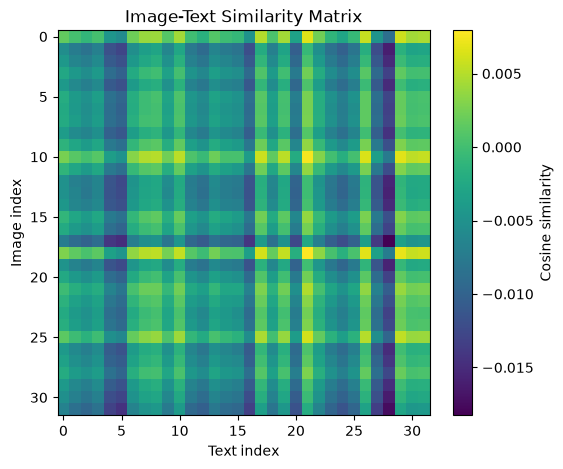

In [177]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(
    similarity.detach().cpu().numpy(),
    aspect="auto",
)

plt.xlabel("Text index")
plt.ylabel("Image index")
plt.title("Image-Text Similarity Matrix")

plt.colorbar(label="Cosine similarity")
plt.show()

## 7. Temperature

The raw similarity values are not yet the final logits used by the classification loss.

We introduce a temperature parameter:

$$
\tau
$$

and calculate:

$$
\text{logits}
=
\frac{S}{\tau}
$$

Temperature controls how sharply the model distinguishes high-similarity pairs from lower-similarity pairs.

A smaller temperature makes the differences between similarities more pronounced.

For this educational implementation we will use the convention:

$$
\text{logits} = \frac{S}{\tau}
$$

and keep that convention consistently throughout the loss implementation.

A commonly used starting value is:

$$
\tau = 0.07
$$

We will keep the temperature explicit so that its effect is easy to understand.

Later, it can be changed to a learnable parameter if the project architecture requires that.

In [178]:
# Temperature used for the current contrastive-loss implementation.

temperature = 0.07

assert temperature > 0

print("Temperature:", temperature)

Temperature: 0.07


## 8. Temperature-Scaled Logits

We now convert the similarity matrix into logits:

$$
L =
\frac{S}{\tau}
$$

The shape does not change.

Therefore:

```text
Similarity
[B, B]

      ↓ divide by temperature

Logits
[B, B]

In [179]:
# Temperature-scaled logits.

logits_per_image = similarity / temperature

print("Logits shape:", logits_per_image.shape)

assert logits_per_image.shape == (
    batch_size,
    batch_size,
)

Logits shape: torch.Size([32, 32])


## 9. Contrastive Labels

The correct text for image $i$ is text $i$.

For a batch of four examples:

```text
Image 0 → Text 0
Image 1 → Text 1
Image 2 → Text 2
Image 3 → Text 3

Therefore the labels are:

[0, 1, 2, 3]

In [180]:
# Correct text index for every image.

labels = torch.arange(
    batch_size,
    device=logits_per_image.device,
)

print("Labels:", labels)

assert labels.shape == (batch_size,)
assert torch.equal(
    labels,
    torch.arange(
        batch_size,
        device=labels.device,
    ),
)

Labels: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])


## 10. Image-to-Text Loss

The first direction asks:

> Given an image, which text in the batch is its matching caption?

Our logits have shape:

$$
[B,B]
$$

where:

- rows = images
- columns = texts

The correct answer for row $i$ is column $i$.

Therefore we can directly use PyTorch's numerically stable cross entropy:

$$
L_{I\rightarrow T}
=
CE(L, labels)
$$




In [181]:
# Image-to-text contrastive loss.

loss_i2t = F.cross_entropy(
    logits_per_image,
    labels,
)

print("Image-to-text loss:", loss_i2t.item())

assert loss_i2t.ndim == 0

Image-to-text loss: 3.467259645462036


## 11. Text-to-Image Loss

CLIP uses the reverse direction as well.

Now we ask:

> Given a text, which image in the batch matches it?

Currently:

```text
logits_per_image

rows    → images
columns → texts

For text-to-image classification, we need:

rows    → texts
columns → images

We therefore transpose the logits

In [182]:
loss_t2i = F.cross_entropy(
    logits_per_image.T,
    labels,
)

In [183]:
# Text-to-image contrastive loss.

loss_t2i = F.cross_entropy(
    logits_per_image.T,
    labels,
)

print("Text-to-image loss:", loss_t2i.item())

assert loss_t2i.ndim == 0

Text-to-image loss: 3.4664692878723145


## 12. Symmetric CLIP Loss

We now have two losses:

### Image → Text

$$
L_{I\rightarrow T}
$$

### Text → Image

$$
L_{T\rightarrow I}
$$

The final CLIP-style loss is their average:

$$
L =
\frac{1}{2}
\left(
L_{I\rightarrow T}
+
L_{T\rightarrow I}
\right)
$$

Both directions contribute to training.

This is important because we want the shared embedding space to work in both directions:

```text
Image → matching Text
Text → matching Image

In [184]:
# Symmetric CLIP contrastive loss.

loss = (
    loss_i2t +
    loss_t2i
) / 2

print("Image-to-text loss:", loss_i2t.item())
print("Text-to-image loss:", loss_t2i.item())
print("Symmetric CLIP loss:", loss.item())

assert loss.ndim == 0

Image-to-text loss: 3.467259645462036
Text-to-image loss: 3.4664692878723145
Symmetric CLIP loss: 3.466864585876465


## 13. Implement a Reusable Contrastive Loss Class

The individual operations above are useful for learning, but during training we want a reusable loss module.

We will therefore package the process into:

```python
CLIPContrastiveLoss

In [185]:
class CLIPContrastiveLoss(nn.Module):
    """
    Symmetric CLIP-style contrastive loss.

    Image embeddings and text embeddings must have the same
    final embedding dimension.

    The loss performs:

        normalize
        ↓
        similarity
        ↓
        temperature scaling
        ↓
        image-to-text CE
        +
        text-to-image CE
        ↓
        symmetric average
    """

    def __init__(self, temperature=0.07):
        super().__init__()

        if temperature <= 0:
            raise ValueError(
                "Temperature must be greater than zero."
            )

        self.temperature = temperature

    def forward(
        self,
        image_embeddings,
        text_embeddings,
        return_details=False,
    ):
        # --------------------------------------------------
        # 1. Normalize both modalities
        # --------------------------------------------------

        image_embeddings = F.normalize(
            image_embeddings,
            dim=-1,
        )

        text_embeddings = F.normalize(
            text_embeddings,
            dim=-1,
        )

        # --------------------------------------------------
        # 2. Similarity matrix
        # --------------------------------------------------

        similarity = (
            image_embeddings
            @ text_embeddings.T
        )

        # --------------------------------------------------
        # 3. Temperature scaling
        # --------------------------------------------------

        logits_per_image = (
            similarity / self.temperature
        )

        # --------------------------------------------------
        # 4. Correct matching indices
        # --------------------------------------------------

        batch_size = image_embeddings.shape[0]

        labels = torch.arange(
            batch_size,
            device=similarity.device,
        )

        # --------------------------------------------------
        # 5. Image-to-text loss
        # --------------------------------------------------

        loss_i2t = F.cross_entropy(
            logits_per_image,
            labels,
        )

        # --------------------------------------------------
        # 6. Text-to-image loss
        # --------------------------------------------------

        loss_t2i = F.cross_entropy(
            logits_per_image.T,
            labels,
        )

        # --------------------------------------------------
        # 7. Symmetric loss
        # --------------------------------------------------

        loss = (
            loss_i2t +
            loss_t2i
        ) / 2

        if return_details:
            return {
                "loss": loss,
                "loss_i2t": loss_i2t,
                "loss_t2i": loss_t2i,
                "similarity": similarity,
                "logits": logits_per_image,
                "labels": labels,
                "temperature": self.temperature,
            }

        return loss

## 14. Instantiate the Contrastive Loss

The loss module now has a single explicit temperature.

For this notebook:

$$
\tau = 0.07
$$

The encoders remain responsible for producing embeddings.

The contrastive-loss module is responsible for comparing those embeddings.

This separation keeps the architecture clean:

```text
Image Encoder
      ↓
Image Embedding
      ↓
                 ┌───────────────┐
Text Encoder     │ Contrastive   │
      ↓          │    Loss       │
Text Embedding → │               │
                 └───────────────┘

In [186]:
contrastive_loss_fn = CLIPContrastiveLoss(
    temperature=temperature,
)

print(contrastive_loss_fn)

CLIPContrastiveLoss()


## 15. Run the Reusable Loss on the Current Batch

We can now replace the manually written contrastive-loss steps with the reusable module.

The encoders are still in evaluation mode here because this is only a forward-pass validation.

No optimizer or training loop is introduced yet.

In [187]:
# ============================================================
# Run Contrastive Loss on Existing Embeddings
# ============================================================

# The embeddings were loaded from the previous notebooks.
# No encoder or DataLoader is needed here.

image_embeddings = image_embeddings.to(DEVICE)
text_embeddings = text_embeddings.to(DEVICE)


# ------------------------------------------------------------
# Run the reusable contrastive loss
# ------------------------------------------------------------

with torch.no_grad():

    contrastive_results = contrastive_loss_fn(
        image_embeddings,
        text_embeddings,
        return_details=True,
    )


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print(
    "Image-to-text loss:",
    contrastive_results["loss_i2t"].item(),
)

print(
    "Text-to-image loss:",
    contrastive_results["loss_t2i"].item(),
)

print(
    "Total CLIP loss:",
    contrastive_results["loss"].item(),
)

print(
    "Similarity shape:",
    contrastive_results["similarity"].shape,
)


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

assert torch.isfinite(
    contrastive_results["loss"]
)

assert contrastive_results["similarity"].shape == (
    image_embeddings.shape[0],
    text_embeddings.shape[0],
)

print("\n✓ Contrastive loss computed successfully.")

Image-to-text loss: 3.467259645462036
Text-to-image loss: 3.4664692878723145
Total CLIP loss: 3.466864585876465
Similarity shape: torch.Size([32, 32])

✓ Contrastive loss computed successfully.


## 16. Tiny Numerical Example

Before relying on the real model, it is useful to understand the loss with a tiny artificial example.

We will use two image embeddings and two text embeddings:

```text
I₁ ↔ T₁
I₂ ↔ T₂

The embeddings are chosen so that:

I₁ is similar to T₁
I₂ is similar to T₂

In [188]:
# Tiny 2-example numerical demonstration

toy_image_embeddings = torch.tensor(
    [
        [1.0, 0.0],
        [0.0, 1.0],
    ],
    dtype=torch.float32,
)

toy_text_embeddings = torch.tensor(
    [
        [1.0, 0.0],
        [0.0, 1.0],
    ],
    dtype=torch.float32,
)

toy_image_embeddings = F.normalize(
    toy_image_embeddings,
    dim=-1,
)

toy_text_embeddings = F.normalize(
    toy_text_embeddings,
    dim=-1,
)

toy_similarity = (
    toy_image_embeddings
    @ toy_text_embeddings.T
)

toy_temperature = 0.1

toy_logits = (
    toy_similarity
    / toy_temperature
)

toy_labels = torch.arange(
    2,
)

toy_loss_i2t = F.cross_entropy(
    toy_logits,
    toy_labels,
)

toy_loss_t2i = F.cross_entropy(
    toy_logits.T,
    toy_labels,
)

toy_loss = (
    toy_loss_i2t +
    toy_loss_t2i
) / 2

print("Toy similarity matrix:")
print(toy_similarity)

print("\nToy logits:")
print(toy_logits)

print("\nLabels:")
print(toy_labels)

print("\nImage-to-text loss:")
print(toy_loss_i2t.item())

print("\nText-to-image loss:")
print(toy_loss_t2i.item())

print("\nSymmetric loss:")
print(toy_loss.item())

Toy similarity matrix:
tensor([[1., 0.],
        [0., 1.]])

Toy logits:
tensor([[10.,  0.],
        [ 0., 10.]])

Labels:
tensor([0, 1])

Image-to-text loss:
4.541770613286644e-05

Text-to-image loss:
4.541770613286644e-05

Symmetric loss:
4.541770613286644e-05


### Interpreting the Tiny Example

The toy similarity matrix is approximately:

```text
             T₁    T₂
I₁          1.0   0.0
I₂          0.0   1.0

The diagonal contains the correct pairs:

I₁ ↔ T₁
I₂ ↔ T₂


## 17. Compare the Manual Calculation with the Loss Class

The reusable loss class should produce the same result as our manually calculated toy example.

This is a useful implementation check because it verifies that the abstraction did not accidentally change the mathematics.

In [189]:
# Verify that the reusable class matches the manual calculation.

toy_loss_fn = CLIPContrastiveLoss(
    temperature=toy_temperature,
)

toy_results = toy_loss_fn(
    toy_image_embeddings,
    toy_text_embeddings,
    return_details=True,
)

print(
    "Manual loss:",
    toy_loss.item(),
)

print(
    "Class loss :",
    toy_results["loss"].item(),
)

assert torch.allclose(
    toy_loss,
    toy_results["loss"],
    atol=1e-6,
)

print("✓ Manual and class implementations match.")

Manual loss: 4.541770613286644e-05
Class loss : 4.541770613286644e-05
✓ Manual and class implementations match.


## 18. Sanity Checks

We now verify the most important properties of the contrastive-loss pipeline.

### Check 1 — Embedding shapes

Both encoders must produce:

$$
[B,D]
$$

### Check 2 — Similarity matrix

The similarity matrix must be:

$$
[B,B]
$$

### Check 3 — Normalization

Every image and text embedding should have approximately unit L2 norm.

### Check 4 — Labels

The labels must be:

$$
[0,1,\ldots,B-1]
$$

### Check 5 — Loss

The final loss must be a scalar.

### Check 6 — Numerical stability

The loss must not contain NaNs or infinities.

In [190]:
# Comprehensive sanity checks.

results = contrastive_loss_fn(
    image_embeddings,
    text_embeddings,
    return_details=True,
)

final_loss = results["loss"]
similarity = results["similarity"]
labels = results["labels"]

B = image_embeddings.shape[0]
D = image_embeddings.shape[1]

# Check embedding shapes
assert image_embeddings.ndim == 2
assert text_embeddings.ndim == 2

assert image_embeddings.shape == (
    B,
    D,
)

assert text_embeddings.shape == (
    B,
    D,
)

# Check similarity matrix
assert similarity.shape == (
    B,
    B,
)

# Check normalized embeddings
image_norms = torch.norm(
    F.normalize(image_embeddings, dim=-1),
    dim=-1,
)

text_norms = torch.norm(
    F.normalize(text_embeddings, dim=-1),
    dim=-1,
)

assert torch.allclose(
    image_norms,
    torch.ones_like(image_norms),
    atol=1e-5,
)

assert torch.allclose(
    text_norms,
    torch.ones_like(text_norms),
    atol=1e-5,
)

# Check labels
expected_labels = torch.arange(
    B,
    device=labels.device,
)

assert torch.equal(
    labels,
    expected_labels,
)

# Check loss
assert final_loss.ndim == 0

# Check for NaN / Inf
assert not torch.isnan(final_loss)
assert not torch.isinf(final_loss)

print("✓ Embedding shapes are correct.")
print("✓ Similarity matrix shape is correct.")
print("✓ Embeddings are normalized.")
print("✓ Labels are correct.")
print("✓ Loss is scalar.")
print("✓ Loss contains no NaN or Inf.")

✓ Embedding shapes are correct.
✓ Similarity matrix shape is correct.
✓ Embeddings are normalized.
✓ Labels are correct.
✓ Loss is scalar.
✓ Loss contains no NaN or Inf.


## 18. Intuition: What Is the Loss Actually Doing?

Consider one image and three captions:

```text
I₁

T₁ = correct caption
T₂ = incorrect caption
T₃ = incorrect caption
Suppose the model currently produces:

similarity(I₁, T₁) = 0.90
similarity(I₁, T₂) = 0.20
similarity(I₁, T₃) = 0.10

## 19. Similarity Matrix Interpretation

The similarity matrix is one of the most important objects in CLIP training.

For a batch:

$$
S \in \mathbb{R}^{B\times B}
$$

we can think of it as a classification table.

For example:

```text
                    Text
              T₁     T₂     T₃
           ┌──────┬──────┬──────┐
Image I₁   │  +   │  -   │  -   │
           ├──────┼──────┼──────┤
Image I₂   │  -   │  +   │  -   │
           ├──────┼──────┼──────┤
Image I₃   │  -   │  -   │  +   │
           └──────┴──────┴──────┘

In [191]:
# ============================================================
# Final Contrastive Loss Verification
# ============================================================

print("=" * 50)
print("FINAL CONTRASTIVE LOSS TEST")
print("=" * 50)

print(
    "Image embedding shape :",
    image_embeddings.shape,
)

print(
    "Text embedding shape  :",
    text_embeddings.shape,
)

print(
    "Similarity shape      :",
    contrastive_results["similarity"].shape,
)

print(
    "Image-to-text loss    :",
    contrastive_results["loss_i2t"].item(),
)

print(
    "Text-to-image loss    :",
    contrastive_results["loss_t2i"].item(),
)

print(
    "Total CLIP loss       :",
    contrastive_results["loss"].item(),
)

print("=" * 50)

assert image_embeddings.shape == text_embeddings.shape

assert contrastive_results["similarity"].shape == (
    image_embeddings.shape[0],
    text_embeddings.shape[0],
)

assert torch.isfinite(
    contrastive_results["loss"]
)

print("✓ Contrastive loss implementation verified.")

FINAL CONTRASTIVE LOSS TEST
Image embedding shape : torch.Size([32, 64])
Text embedding shape  : torch.Size([32, 64])
Similarity shape      : torch.Size([32, 32])
Image-to-text loss    : 3.467259645462036
Text-to-image loss    : 3.4664692878723145
Total CLIP loss       : 3.466864585876465
✓ Contrastive loss implementation verified.


In [192]:
# ============================================================
# Contrastive Loss — Implementation and Verification
# ============================================================


# ------------------------------------------------------------
# Symmetric CLIP-style contrastive loss
# ------------------------------------------------------------

def contrastive_loss(
    image_embeddings,
    text_embeddings,
    temperature=0.07,
):
    """
    Compute symmetric image-text contrastive loss.

    Image embeddings:
        [B, D]

    Text embeddings:
        [B, D]

    Similarity matrix:
        [B, B]
    """

    # L2-normalize both modalities
    image_embeddings = F.normalize(
        image_embeddings,
        dim=-1,
    )

    text_embeddings = F.normalize(
        text_embeddings,
        dim=-1,
    )

    # Image-to-text similarity
    similarity = (
        image_embeddings @ text_embeddings.T
    )

    # Temperature scaling
    logits = similarity / temperature

    # Correct pair for each sample is on the diagonal
    labels = torch.arange(
        logits.shape[0],
        device=logits.device,
    )

    # Image -> Text
    loss_image_to_text = F.cross_entropy(
        logits,
        labels,
    )

    # Text -> Image
    loss_text_to_image = F.cross_entropy(
        logits.T,
        labels,
    )

    # Symmetric loss
    loss = (
        loss_image_to_text
        + loss_text_to_image
    ) / 2

    return loss, similarity


# ------------------------------------------------------------
# Compute contrastive loss
# ------------------------------------------------------------

loss, similarity = contrastive_loss(
    image_embeddings,
    text_embeddings,
)


# ------------------------------------------------------------
# Verify results
# ------------------------------------------------------------

print("Similarity matrix shape:", similarity.shape)
print("Contrastive loss:", loss.item())

assert similarity.ndim == 2

assert similarity.shape[0] == image_embeddings.shape[0]

assert similarity.shape[1] == text_embeddings.shape[0]

assert torch.isfinite(loss)


# ------------------------------------------------------------
# Inspect diagonal similarities
# ------------------------------------------------------------

diagonal_similarity = torch.diag(similarity)

print(
    "Mean positive-pair similarity:",
    diagonal_similarity.mean().item(),
)


# ------------------------------------------------------------
# Save initial contrastive-loss results
# ------------------------------------------------------------

contrastive_artifact = {
    "loss": loss.detach().cpu(),
    "similarity_matrix": similarity.detach().cpu(),
    "temperature": 0.07,
}

contrastive_path = (
    MODEL_ARTIFACTS_DIR /
    "contrastive_loss_initial.pt"
)

torch.save(
    contrastive_artifact,
    contrastive_path,
)


print("\nContrastive loss artifact saved:")
print("✓", contrastive_path)

Similarity matrix shape: torch.Size([32, 32])
Contrastive loss: 3.466864585876465
Mean positive-pair similarity: -0.003967554308474064

Contrastive loss artifact saved:
✓ d:\github\Build A NanoVLM From SCRATCH\artifacts\models\contrastive_loss_initial.pt


# 20. Final Summary

We have now implemented the CLIP-style symmetric contrastive objective from scratch.

The complete pipeline is:

```text
Image Encoder
      ↓
Image Embedding
      ↓
L2 Normalize
      ↓
      ├───────────────┐
      │               │
      ↓               ↓
              Similarity Matrix
              S = ZI ZTᵀ
                    ↓
            Temperature Scaling
                    ↓
          ┌─────────┴─────────┐
          ↓                   ↓
   Image-to-Text        Text-to-Image
       Loss                 Loss
          └─────────┬─────────┘
                    ↓
          Symmetric CLIP Loss

### One implementation note

I intentionally kept the temperature **fixed at `0.07`** here rather than silently introducing a learnable `logit_scale`, because the contrastive-loss mathematics in this section explicitly uses:

```python
logits = similarity / temperature